# Workload-aware hardware-model-workload suitability framework

No single inference metric represents practical usability. Chat prioritizes latency and generation speed; coding and agentic workloads need stronger prompt processing; summarization depends heavily on prefill; and quality prevents recommending fast but low-capability models.

These thresholds are analytical criteria defined for this study and do not represent universal industry requirements.

In [32]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'analysis').exists(): PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))
import matplotlib.pyplot as plt
import pandas as pd
from analysis.utils import load_dataset, save_figure, save_table
data = load_dataset(PROJECT_ROOT / 'results' / 'processed' / 'final-analysis-dataset.csv')
print(f'Loaded {len(data):,} rows and {len(data.columns):,} columns')

Loaded 630 rows and 37 columns


## Workload-specific weights and thresholds

Scores use min-max normalization from 0 to 100. Missing metrics are excluded and the remaining weights are renormalized.

In [33]:
WORKLOAD_WEIGHTS = {
    'chat': {'ttft': .30, 'decode': .35, 'quality': .25, 'prefill': .10},
    'coding': {'prefill': .30, 'decode': .30, 'quality': .30, 'ttft': .10},
    'agentic': {'prefill': .40, 'quality': .30, 'decode': .20, 'memory': .10},
    'summarization': {'prefill': .45, 'quality': .35, 'decode': .10, 'ttft': .10},
    'batch': {'prefill': .35, 'decode': .25, 'quality': .25, 'memory': .15},
    'world_knowledge': {'quality': .50, 'ttft': .20, 'decode': .20, 'prefill': .10},
}
SUITABLE_THRESHOLD, CONDITIONAL_THRESHOLD = 70.0, 45.0

## Aggregated configuration metrics

Repeated successful benchmark runs are averaged by hardware, model, and workload. RAM and VRAM are retained separately; the relevant resource for normalization is VRAM for CUDA and RAM otherwise. Model metadata is retained.

In [34]:
successful = data.loc[data['status'].eq('success')].copy()
successful['memory_usage_mb'] = successful['vram_usage'].where(successful['backend'].eq('cuda'), successful['ram_usage'])
configuration = successful.groupby(['hardware', 'model', 'workload'], as_index=False).agg(
    prompt_eval_tps=('prompt_eval_tps', 'mean'), decode_tps=('decode_tps', 'mean'), time_to_first_token=('time_to_first_token', 'mean'),
    overall_score=('overall_score', 'mean'), ram_usage=('ram_usage', 'mean'), vram_usage=('vram_usage', 'mean'), memory_usage_mb=('memory_usage_mb', 'mean'),
    model_size_b=('model_size_b', 'first'), architecture=('architecture', 'first'), model_family=('model_family', 'first'), active_parameters_b=('active_parameters_b', 'first'),
    executions=('experiment_id', 'size'))
print(f'Aggregated {len(configuration):,} successful configurations')

Aggregated 209 successful configurations


## Min-max normalized metric scores

Prefill, decode, and quality are higher-is-better. TTFT and memory efficiency invert min-max values because lower latency and lower resource usage are better. Constant metrics receive 100 for available values.

In [35]:
def min_max_score(series, higher_is_better=True):
    score = pd.Series(float('nan'), index=series.index, dtype='float64')
    valid = series.notna()
    if not valid.any(): return score
    low, high = series.loc[valid].min(), series.loc[valid].max()
    if low == high: score.loc[valid] = 100.0
    else:
        normalized = (series.loc[valid] - low) / (high - low) * 100.0
        score.loc[valid] = normalized if higher_is_better else 100.0 - normalized
    return score
configuration['prefill_score'] = min_max_score(configuration['prompt_eval_tps'])
configuration['decode_score'] = min_max_score(configuration['decode_tps'])
configuration['ttft_score'] = min_max_score(configuration['time_to_first_token'], False)
configuration['quality_score'] = min_max_score(configuration['overall_score'])
configuration['memory_efficiency_score'] = min_max_score(configuration['memory_usage_mb'], False)

## Workload suitability score and classification

The weighted workload score is between 0 and 100. Suitable means score >= 70; Conditionally suitable means score >= 45 and < 70; Not practical means score < 45.

In [36]:
SCORE_COLUMNS = {'prefill':'prefill_score', 'decode':'decode_score', 'ttft':'ttft_score', 'quality':'quality_score', 'memory':'memory_efficiency_score'}
def workload_score(row):
    weights = WORKLOAD_WEIGHTS.get(row['workload'], {})
    available = {m: row[SCORE_COLUMNS[m]] for m in weights if pd.notna(row[SCORE_COLUMNS[m]])}
    if not available: return float('nan')
    total = sum(weights[m] for m in available)
    return sum(available[m] * weights[m] for m in available) / total
configuration['workload_suitability_score'] = configuration.apply(workload_score, axis=1)
configuration['classification'] = 'Not practical'
configuration.loc[configuration['workload_suitability_score'].ge(CONDITIONAL_THRESHOLD), 'classification'] = 'Conditionally suitable'
configuration.loc[configuration['workload_suitability_score'].ge(SUITABLE_THRESHOLD), 'classification'] = 'Suitable'
ranking = configuration.rename(columns={'workload_suitability_score':'suitability_score', 'time_to_first_token':'TTFT', 'vram_usage':'VRAM', 'ram_usage':'RAM'})[['hardware','model','workload','architecture','suitability_score','classification','decode_tps','prompt_eval_tps','TTFT','overall_score','VRAM','RAM']].sort_values(['workload','suitability_score'], ascending=[True,False])
display(ranking)
save_table(ranking, '06_hardware_model_workload_suitability_ranking.csv')

,hardware,model,workload,architecture,suitability_score,classification,decode_tps,prompt_eval_tps,TTFT,overall_score,VRAM,RAM
125,rtx2060-12gb,Qwen3.5-0.8B,agentic,dense,58.471837,Conditionally suitable,202.100000,4934.833333,1.239165,3.00,1052.0,1645.333333
131,rtx2060-12gb,Qwen3.5-2B,agentic,dense,54.191689,Conditionally suitable,153.200000,3176.866667,1.523297,3.75,1496.0,1656.333333
143,rtx2060-12gb,Qwen3.5-9B,agentic,dense,46.851739,Conditionally suitable,48.733333,1094.133333,2.528157,5.00,5348.0,1745.000000
173,rtx2060-12gb,gemma-4-E2B-it,agentic,MoE,42.812592,Not practical,117.133333,2520.900000,1.992593,3.50,1744.0,1707.666667
48,gtx1660-super-6gb,Qwen3.5-9B,agentic,dense,40.510903,Not practical,40.766667,141.266667,5.989795,5.00,5322.0,1681.666667
...,...,...,...,...,...,...,...,...,...,...,...,...
11,gtx1650-4gb,Qwen3.5-0.8B,world_knowledge,dense,31.125921,Not practical,102.466667,868.200000,1.763726,3.00,1010.0,1560.333333
184,ryzen5600,Qwen3.5-0.8B,world_knowledge,dense,27.848910,Not practical,20.866667,74.800000,8.382435,3.25,9.0,1694.333333
106,i7-4790k,Qwen3.5-0.8B,world_knowledge,dense,20.763377,Not practical,15.133333,46.966667,13.152658,3.00,NaN,1171.666667
82,i5-8265U,Qwen3.5-0.8B,world_knowledge,dense,20.340685,Not practical,11.900000,41.033333,15.131223,3.00,NaN,1092.333333


WindowsPath('D:/Projects/efficient-llm-inference-research/analysis/tables/06_hardware_model_workload_suitability_ranking.csv')

## Top suitability configurations per workload

This table presents the highest-ranked hardware-model combinations for each workload based on the workload-aware suitability framework. Rankings should be interpreted as workload-specific recommendations rather than a universal hardware ranking.

In [37]:
top_suitability = (
    configuration.sort_values('workload_suitability_score', ascending=False)
    .groupby('workload', group_keys=False)
    .head(5)
)
top_suitability = top_suitability.rename(columns={
    'workload_suitability_score': 'suitability_score',
})[[
    'workload', 'hardware', 'model', 'architecture', 'suitability_score',
    'classification', 'decode_tps', 'prompt_eval_tps', 'time_to_first_token',
    'overall_score', 'vram_usage', 'ram_usage',
]]
display(top_suitability)
save_table(top_suitability, 'top_suitability_configurations.csv')

,workload,hardware,model,architecture,suitability_score,classification,decode_tps,prompt_eval_tps,time_to_first_token,overall_score,vram_usage,ram_usage
148,world_knowledge,rtx2060-12gb,Qwen3.5-9B,dense,76.198314,Suitable,49.633333,1085.900000,2.510309,5.00,5348.0,1768.333333
127,chat,rtx2060-12gb,Qwen3.5-0.8B,dense,74.698588,Suitable,204.966667,4513.733333,1.541563,3.25,1000.0,1605.333333
160,world_knowledge,rtx2060-12gb,Qwen3.6-35B-A3B,MoE,73.986268,Suitable,40.233333,308.600000,5.571067,5.00,11592.0,1864.000000
53,world_knowledge,gtx1660-super-6gb,Qwen3.5-9B,dense,73.935903,Suitable,42.366667,141.166667,5.896651,5.00,5322.0,1663.333333
172,world_knowledge,rtx2060-12gb,gemma-4-26B-A4B-it,MoE,73.705383,Suitable,34.466667,485.166667,4.960618,5.00,11634.0,1840.000000
129,summarization,rtx2060-12gb,Qwen3.5-0.8B,dense,73.498611,Suitable,200.033333,6838.000000,1.546419,3.50,1052.0,1696.000000
133,chat,rtx2060-12gb,Qwen3.5-2B,dense,73.114331,Suitable,154.566667,2979.133333,1.744095,4.00,1444.0,1584.666667
59,world_knowledge,gtx1660-super-6gb,Qwen3.6-35B-A3B,MoE,72.555814,Suitable,30.900000,87.033333,9.432358,5.00,5534.0,1782.666667
175,chat,rtx2060-12gb,gemma-4-E2B-it,MoE,65.863449,Conditionally suitable,118.333333,2349.533333,2.797166,4.00,1712.0,1690.333333
38,chat,gtx1660-super-6gb,Qwen3.5-2B,dense,65.810918,Conditionally suitable,132.766667,584.866667,2.246519,4.00,1416.0,1511.000000


WindowsPath('D:/Projects/efficient-llm-inference-research/analysis/tables/top_suitability_configurations.csv')

## Overall suitability score by workload

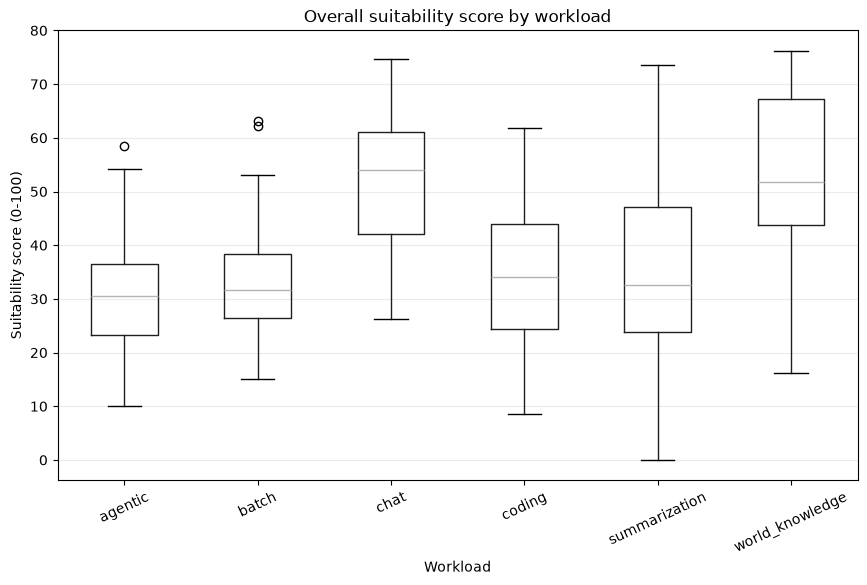

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
ranking.boxplot(column='suitability_score', by='workload', ax=ax, grid=False)
ax.set_title('Overall suitability score by workload'); fig.suptitle('')
ax.set_xlabel('Workload'); ax.set_ylabel('Suitability score (0-100)'); ax.tick_params(axis='x', rotation=25); ax.grid(axis='y', alpha=.25)
save_figure(fig, '06_suitability_score_by_workload.png'); plt.show()

## Suitability heatmap

Rows are hardware and columns are workloads; values are average suitability scores across models.

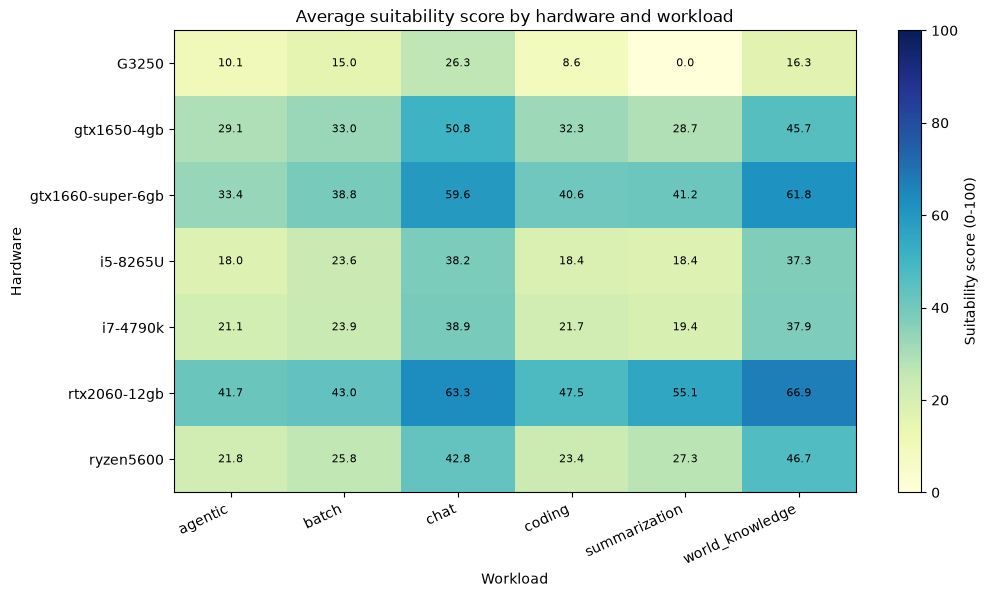

In [39]:
heatmap = ranking.pivot_table(index='hardware', columns='workload', values='suitability_score', aggfunc='mean')
fig, ax = plt.subplots(figsize=(11, 6)); image = ax.imshow(heatmap, cmap='YlGnBu', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(heatmap.columns)), labels=heatmap.columns, rotation=25, ha='right'); ax.set_yticks(range(len(heatmap.index)), labels=heatmap.index)
for i in range(len(heatmap.index)):
    for j in range(len(heatmap.columns)):
        if pd.notna(heatmap.iloc[i, j]): ax.text(j, i, f'{heatmap.iloc[i, j]:.1f}', ha='center', va='center', fontsize=8)
ax.set_title('Average suitability score by hardware and workload'); ax.set_xlabel('Workload'); ax.set_ylabel('Hardware'); fig.colorbar(image, ax=ax, label='Suitability score (0-100)')
save_figure(fig, '06_suitability_heatmap.png'); plt.show()

## Performance-quality trade-off

Quality remains visible so a high suitability score is not interpreted as a recommendation for a configuration with weak measured quality.

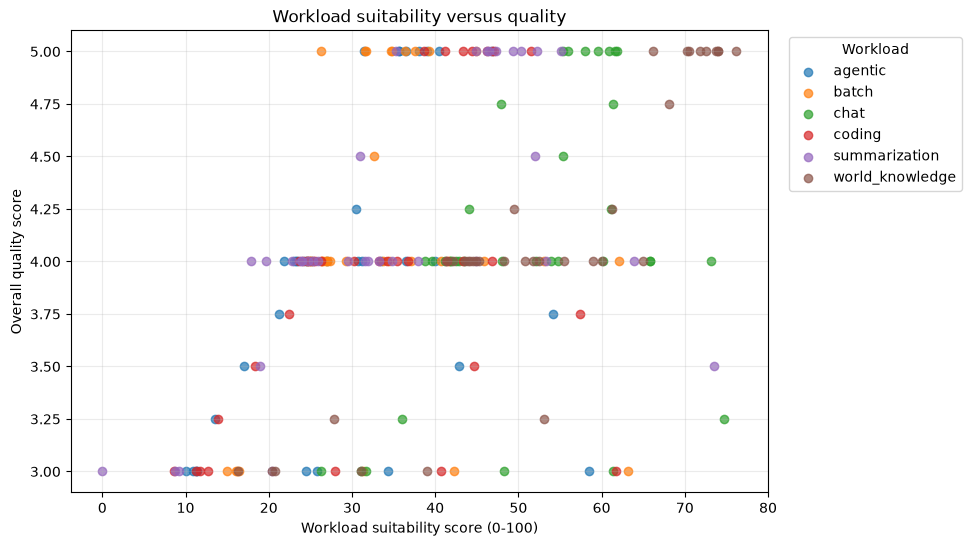

In [40]:
fig, ax = plt.subplots(figsize=(9, 6))
for workload, subset in ranking.dropna(subset=['suitability_score','overall_score']).groupby('workload'):
    ax.scatter(subset['suitability_score'], subset['overall_score'], label=workload, alpha=.7)
ax.set_title('Workload suitability versus quality'); ax.set_xlabel('Workload suitability score (0-100)'); ax.set_ylabel('Overall quality score'); ax.legend(title='Workload', bbox_to_anchor=(1.02,1), loc='upper left'); ax.grid(alpha=.25)
save_figure(fig, '06_suitability_vs_quality.png'); plt.show()

## Prefill versus decode performance

The highest-scoring configurations are annotated to show important hardware-model-workload combinations.

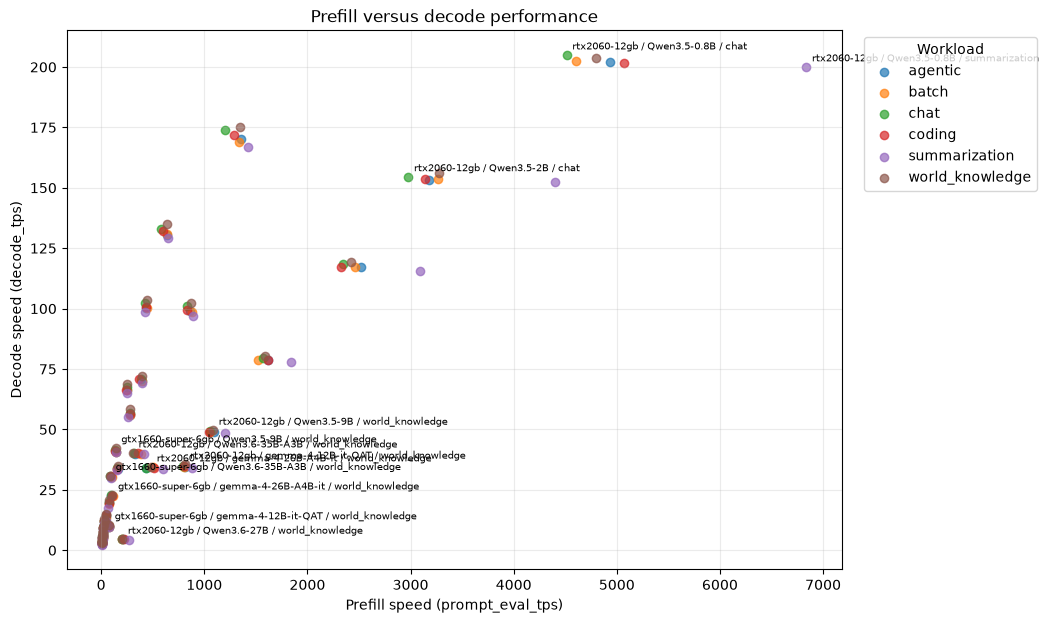

In [41]:
plot_data = ranking.dropna(subset=['prompt_eval_tps','decode_tps','suitability_score'])
fig, ax = plt.subplots(figsize=(10, 7))
for workload, subset in plot_data.groupby('workload'):
    ax.scatter(subset['prompt_eval_tps'], subset['decode_tps'], label=workload, alpha=.7)
important = plot_data.nlargest(min(12, len(plot_data)), 'suitability_score')
for _, row in important.iterrows(): ax.annotate(f"{row['hardware']} / {row['model']} / {row['workload']}", (row['prompt_eval_tps'], row['decode_tps']), xytext=(4,4), textcoords='offset points', fontsize=7)
ax.set_title('Prefill versus decode performance'); ax.set_xlabel('Prefill speed (prompt_eval_tps)'); ax.set_ylabel('Decode speed (decode_tps)'); ax.legend(title='Workload', bbox_to_anchor=(1.02,1), loc='upper left'); ax.grid(alpha=.25)
save_figure(fig, '06_prefill_vs_decode.png'); plt.show()